In [1]:
# 05 - PREPARE EVALUATION RESULTS

import pandas as pd
import numpy as np
import re
import os

# Load Flan-T5 results (sentence-level experiment)
zs_flan = pd.read_csv("../outputs/zero_shot_results.csv")
fs_flan = pd.read_csv("../outputs/few_shot_results.csv")

print(f" Flan-T5 zero-shot: {len(zs_flan)} rows")
print(f" Flan-T5 few-shot:  {len(fs_flan)} rows")
print(f"   Columns: {list(zs_flan.columns)}")

 Flan-T5 zero-shot: 100 rows
 Flan-T5 few-shot:  100 rows
   Columns: ['sentence', 'true_label', 'population', 'intervention', 'outcome']


In [2]:
# Load Qwen results (abstract-level experiment)
# Generated by notebook 04 on 178 official test documents

zs_qwen = pd.read_csv("../outputs/axis2A_zero_shot_qwen_results.csv")
fs_qwen = pd.read_csv("../outputs/axis2A_few_shot_qwen_results.csv")

print(f" Qwen zero-shot: {len(zs_qwen)} rows")
print(f" Qwen few-shot:  {len(fs_qwen)} rows")
print(f"   Columns: {list(zs_qwen.columns)}")

 Qwen zero-shot: 178 rows
 Qwen few-shot:  178 rows
   Columns: ['doc_id', 'abstract_text', 'gold_participants', 'gold_interventions', 'gold_outcomes', 'pred_participants', 'pred_interventions', 'pred_outcomes', 'raw_model_output']


In [3]:
# EVALUATE QWEN RESULTS
# Token-level F1 for each PICO field

def normalize_text(text):
    if pd.isna(text) or text is None:
        return ""
    text = str(text).lower().strip()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def token_f1(pred, gold):
    pred = normalize_text(pred)
    gold = normalize_text(gold)
    pred_tokens = set(pred.split())
    gold_tokens = set(gold.split())
    if not pred_tokens and not gold_tokens:
        return 1.0, 1.0, 1.0
    if not pred_tokens or not gold_tokens:
        return 0.0, 0.0, 0.0
    overlap   = len(pred_tokens & gold_tokens)
    precision = overlap / len(pred_tokens)
    recall    = overlap / len(gold_tokens)
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    return precision, recall, f1

def evaluate_approach(df, approach_name):
    fields = [
        ("participants",  "gold_participants",  "pred_participants"),
        ("interventions", "gold_interventions", "pred_interventions"),
        ("outcomes",      "gold_outcomes",      "pred_outcomes"),
    ]
    results = []
    for field_name, gold_col, pred_col in fields:
        precisions, recalls, f1s, coverages = [], [], [], []
        for _, row in df.iterrows():
            p, r, f1 = token_f1(row[pred_col], row[gold_col])
            precisions.append(p)
            recalls.append(r)
            f1s.append(f1)
            coverages.append(1 if normalize_text(row[pred_col]) != "" else 0)
        results.append({
            "approach":  approach_name,
            "field":     field_name,
            "precision": round(np.mean(precisions), 4),
            "recall":    round(np.mean(recalls),    4),
            "f1":        round(np.mean(f1s),        4),
            "coverage":  round(np.mean(coverages),  4),
        })
    return pd.DataFrame(results)

# Run evaluation
zs_eval = evaluate_approach(zs_qwen, "axis2A_Zero_Shot_qwen")
fs_eval = evaluate_approach(fs_qwen, "axis2A_Few_Shot_qwen")

print("="*60)
print(" QWEN EVALUATION RESULTS (178 official test documents)")
print("="*60)

print(f"\nZero-shot (Overall F1: {zs_eval['f1'].mean():.4f})")
print(f"{'Field':15} {'Precision':10} {'Recall':10} {'F1':10} {'Coverage':10}")
print("-"*55)
for _, row in zs_eval.iterrows():
    print(f"  {row['field']:13} {row['precision']:10.4f} {row['recall']:10.4f} {row['f1']:10.4f} {row['coverage']:10.4f}")

print(f"\nFew-shot (Overall F1: {fs_eval['f1'].mean():.4f})")
print(f"{'Field':15} {'Precision':10} {'Recall':10} {'F1':10} {'Coverage':10}")
print("-"*55)
for _, row in fs_eval.iterrows():
    print(f"  {row['field']:13} {row['precision']:10.4f} {row['recall']:10.4f} {row['f1']:10.4f} {row['coverage']:10.4f}")

 QWEN EVALUATION RESULTS (178 official test documents)

Zero-shot (Overall F1: 0.2172)
Field           Precision  Recall     F1         Coverage  
-------------------------------------------------------
  participants      0.3456     0.1419     0.1778     0.9157
  interventions     0.4863     0.1368     0.1926     0.9101
  outcomes          0.4528     0.2598     0.2811     0.8989

Few-shot (Overall F1: 0.1898)
Field           Precision  Recall     F1         Coverage  
-------------------------------------------------------
  participants      0.3166     0.1168     0.1547     0.9944
  interventions     0.5000     0.1207     0.1727     0.9775
  outcomes          0.3795     0.2679     0.2421     0.9944


In [4]:
# FLAN-T5 SUMMARY
# Documented separately — binary metric
# Cannot use token F1 (no doc-level gold labels)

flant5_summary = pd.DataFrame({
    "approach":      ["axis2A_Zero_Shot_flant5", "axis2A_Few_Shot_flant5"],
    "metric":        ["binary_success_rate",      "binary_success_rate"],
    "participants":  [44.0, 16.0],
    "interventions": [40.0,  8.0],
    "outcomes":      [88.0, 56.0],
    "overall":       [57.3, 26.7],
    "note":          [
        "Sentence-level input, binary success metric",
        "Sentence-level input, binary success metric"
    ]
})

flant5_summary.to_csv("../outputs/axis2A_flant5_binary_summary.csv", index=False)
print(" Flan-T5 summary saved: axis2A_flant5_binary_summary.csv")
print("\nFlan-T5 cannot be compared directly with Qwen using token F1")
print("because it operated on single sentences without doc-level gold labels.")
print("Reported separately using binary success rate metric.")
print(flant5_summary.to_string(index=False))

 Flan-T5 summary saved: axis2A_flant5_binary_summary.csv

Flan-T5 cannot be compared directly with Qwen using token F1
because it operated on single sentences without doc-level gold labels.
Reported separately using binary success rate metric.
               approach              metric  participants  interventions  outcomes  overall                                        note
axis2A_Zero_Shot_flant5 binary_success_rate          44.0           40.0      88.0     57.3 Sentence-level input, binary success metric
 axis2A_Few_Shot_flant5 binary_success_rate          16.0            8.0      56.0     26.7 Sentence-level input, binary success metric


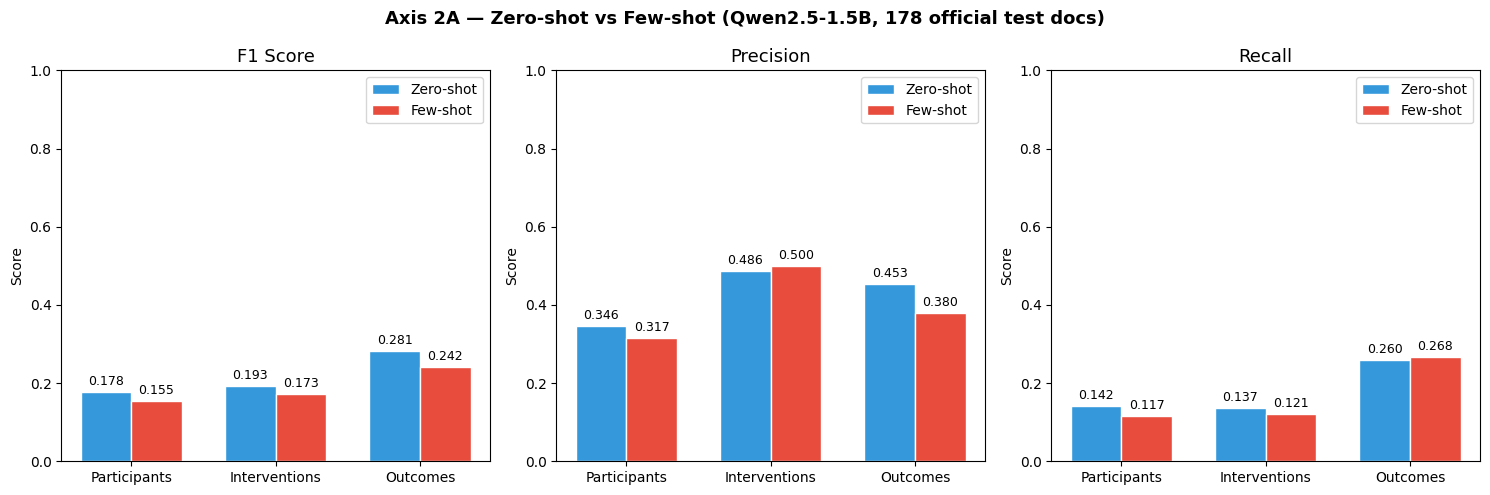

 Saved axis2A_qwen_evaluation.png


In [5]:
# SAVE EVALUATION SUMMARY

import matplotlib.pyplot as plt

# Combined evaluation table
eval_combined = pd.concat([zs_eval, fs_eval], ignore_index=True)
eval_combined.to_csv("../outputs/axis2A_qwen_evaluation_summary.csv", index=False)

# Visualisation
fields    = ["Participants", "Interventions", "Outcomes"]
zs_f1     = zs_eval["f1"].tolist()
fs_f1     = fs_eval["f1"].tolist()
zs_prec   = zs_eval["precision"].tolist()
fs_prec   = fs_eval["precision"].tolist()
zs_rec    = zs_eval["recall"].tolist()
fs_rec    = fs_eval["recall"].tolist()

x     = np.arange(len(fields))
width = 0.35

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (zs_vals, fs_vals, title) in zip(axes, [
    (zs_f1,  fs_f1,  "F1 Score"),
    (zs_prec, fs_prec, "Precision"),
    (zs_rec,  fs_rec,  "Recall"),
]):
    bars1 = ax.bar(x - width/2, zs_vals, width, label="Zero-shot", color="#3498db", edgecolor="white")
    bars2 = ax.bar(x + width/2, fs_vals, width, label="Few-shot",  color="#e74c3c", edgecolor="white")
    ax.set_title(title, fontsize=13)
    ax.set_xticks(x)
    ax.set_xticklabels(fields)
    ax.set_ylim(0, 1)
    ax.legend()
    ax.set_ylabel("Score")
    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f"{bar.get_height():.3f}",
                ha="center", va="bottom", fontsize=9)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f"{bar.get_height():.3f}",
                ha="center", va="bottom", fontsize=9)

plt.suptitle("Axis 2A — Zero-shot vs Few-shot (Qwen2.5-1.5B, 178 official test docs)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/axis2A_qwen_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Saved axis2A_qwen_evaluation.png")

In [6]:
# GENERATE FINAL PREDICTION FILES

# Zero-shot
zs_pred = pd.DataFrame({
    "doc_id":             zs_qwen["doc_id"],
    "participants_pred":  zs_qwen["pred_participants"],
    "interventions_pred": zs_qwen["pred_interventions"],
    "outcomes_pred":      zs_qwen["pred_outcomes"],
    "variant":            "axis2A_Zero_Shot_qwen"
})

# Few-shot
fs_pred = pd.DataFrame({
    "doc_id":             fs_qwen["doc_id"],
    "participants_pred":  fs_qwen["pred_participants"],
    "interventions_pred": fs_qwen["pred_interventions"],
    "outcomes_pred":      fs_qwen["pred_outcomes"],
    "variant":            "axis2A_Few_Shot_qwen"
})

# Save
zs_pred.to_csv("../outputs/axis2A_Zero_Shot_qwen_pred.csv", index=False)
fs_pred.to_csv("../outputs/axis2A_Few_Shot_qwen_pred.csv",  index=False)

print("="*55)
print("FINAL PREDICTION FILES SAVED")
print("="*55)
print("Submit THESE files:")
print("   → axis2A_Zero_Shot_qwen_pred.csv")
print("   → axis2A_Few_Shot_qwen_pred.csv")
print(f"\nColumns: {list(zs_pred.columns)}")
print(f"Rows: {len(zs_pred)}")
print(f"\nSample row:")
print(zs_pred.iloc[0])

FINAL PREDICTION FILES SAVED
Submit THESE files:
   → axis2A_Zero_Shot_qwen_pred.csv
   → axis2A_Few_Shot_qwen_pred.csv

Columns: ['doc_id', 'participants_pred', 'interventions_pred', 'outcomes_pred', 'variant']
Rows: 178

Sample row:
doc_id                                                           361799
participants_pred                                          603 patients
interventions_pred    Vincristine + Cyclophosphamide + 5-fluorouraci...
outcomes_pred         Results better than 50%; Quality of results; D...
variant                                           axis2A_Zero_Shot_qwen
Name: 0, dtype: object
